In [1]:

!pip install torch torchvision matplotlib

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=128, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 60.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.71MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.0MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.48MB/s]


In [3]:
class VAE(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 400)
        self.fc_mu = nn.Linear(400, 2)
        self.fc_logvar = nn.Linear(400, 2)
        self.fc2 = nn.Linear(2, 400)
        self.fc3 = nn.Linear(400, 784)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return torch.sigmoid(self.fc3(h))

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

In [4]:
model = VAE()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def loss_fn(recon, x, mu, logvar):
    BCE = nn.functional.binary_cross_entropy(recon, x, reduction='sum')
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return BCE + KLD

In [5]:
epochs = 5

for epoch in range(epochs):
    total_loss = 0
    for data, _ in train_loader:
        data = data.view(-1, 784)

        recon, mu, logvar = model(data)
        loss = loss_fn(recon, data, mu, logvar)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.2f}")

Epoch 1, Loss: 11380958.20
Epoch 2, Loss: 10119472.06
Epoch 3, Loss: 9865789.20
Epoch 4, Loss: 9716346.88
Epoch 5, Loss: 9611641.50


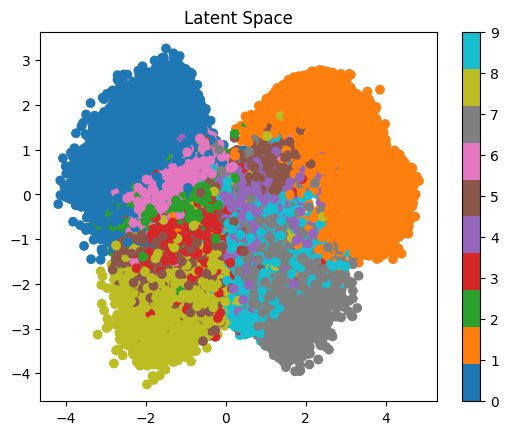

In [6]:
import numpy as np

zs = []
labels = []

with torch.no_grad():
    for data, label in train_loader:
        data = data.view(-1, 784)
        mu, _ = model.encode(data)
        zs.append(mu)
        labels.append(label)

zs = torch.cat(zs).numpy()
labels = torch.cat(labels).numpy()

plt.scatter(zs[:,0], zs[:,1], c=labels, cmap='tab10')
plt.colorbar()
plt.title("Latent Space")
plt.show()

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [8]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

dataset = datasets.MNIST(root='./data', train=True, transform=transform, download=True)
loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)

In [9]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(100, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)

class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(784, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [10]:
G = Generator()
D = Discriminator()

loss_fn = nn.BCELoss()

opt_G = optim.Adam(G.parameters(), lr=0.0002)
opt_D = optim.Adam(D.parameters(), lr=0.0002)

In [11]:
epochs = 5

for epoch in range(epochs):
    for real, _ in loader:
        real = real.view(-1, 784)

        # Train Discriminator
        noise = torch.randn(real.size(0), 100)
        fake = G(noise)

        loss_D = loss_fn(D(real), torch.ones(real.size(0),1)) + \
                 loss_fn(D(fake.detach()), torch.zeros(real.size(0),1))

        opt_D.zero_grad()
        loss_D.backward()
        opt_D.step()

        # Train Generator
        loss_G = loss_fn(D(fake), torch.ones(real.size(0),1))

        opt_G.zero_grad()
        loss_G.backward()
        opt_G.step()

    print(f"Epoch {epoch+1} completed")

Epoch 1 completed
Epoch 2 completed
Epoch 3 completed
Epoch 4 completed
Epoch 5 completed


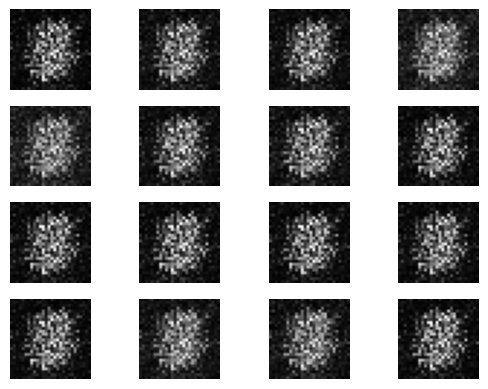

In [12]:
noise = torch.randn(16, 100)
fake_images = G(noise).detach().view(-1, 28, 28)

fig, axes = plt.subplots(4, 4)
for i, ax in enumerate(axes.flat):
    ax.imshow(fake_images[i], cmap='gray')
    ax.axis('off')

plt.show()

In [13]:
!pip install torch-geometric

import torch
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 23.4 MB/s eta 0:00:00a 0:00:01


In [14]:
dataset = Planetoid(root='data', name='Cora')
data = dataset[0]

print(data)

Processing...


Data(x=[2708, 1433], edge_index=[2, 10556], y=[2708], train_mask=[2708], val_mask=[2708], test_mask=[2708])


Done!


In [15]:
class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(dataset.num_features, 16)
        self.conv2 = GCNConv(16, dataset.num_classes)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = F.relu(self.conv1(x, edge_index))
        x = self.conv2(x, edge_index)
        return F.log_softmax(x, dim=1)

In [16]:
model = GCN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [17]:
for epoch in range(100):
    model.train()
    optimizer.zero_grad()

    out = model(data)
    loss = F.nll_loss(out[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

Epoch 0, Loss: 1.9435
Epoch 10, Loss: 0.6342
Epoch 20, Loss: 0.1359
Epoch 30, Loss: 0.0300
Epoch 40, Loss: 0.0105
Epoch 50, Loss: 0.0055
Epoch 60, Loss: 0.0037
Epoch 70, Loss: 0.0029
Epoch 80, Loss: 0.0024
Epoch 90, Loss: 0.0021


In [18]:
model.eval()
pred = model(data).argmax(dim=1)

correct = (pred[data.test_mask] == data.y[data.test_mask]).sum()
acc = int(correct) / int(data.test_mask.sum())

print("Accuracy:", acc)

Accuracy: 0.783
